/Users/huangjinjin/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


>>> Data preprocessing in progress...
>>> After preprocessing, cells: 5227; genes: 9396;
>>> Feature selection in progress...
>>> Identification of HVGs is currently in progress...
>>> Identification of RFGs is currently in progress...
>>> After feature selection, genes: 3247;
>>> Clusters decomposition in progress...
>>> iter 1, running...
>>> After clusters decomposition, we got 60 balanced sub-clusters.
>>> Clusters merge in progress...


100%|██████████| 7/7 [00:00<00:00, 1829.98it/s]


>>> After clusters merge, we got 37 sub-clusters.
>>> Cluster anomaly score calculation in progress...


100%|██████████| 37/37 [00:07<00:00,  4.73it/s]


>>> time used: 83.52142286300659


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


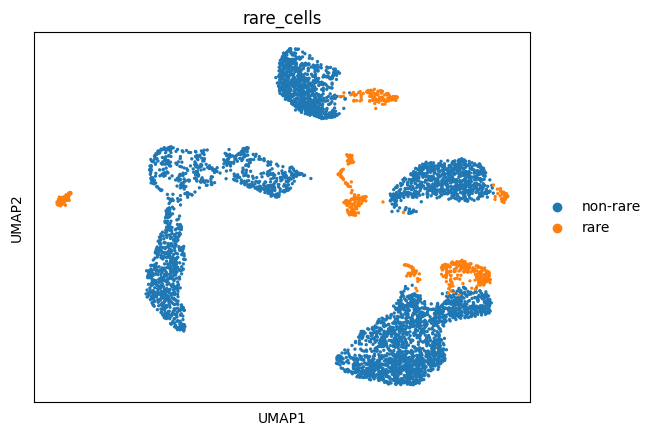

In [1]:
import scanpy as sc
import numpy as np
from scCAD import scCAD  # 假设scCAD函数在单独的文件中或者已经安装为一个包
import pandas as pd

# 读取数据
adataRaw = sc.read_h5ad("../output/pbmc_benchmark_data/pbmc_benchmark_s1d1.h5ad")
adataRaw.var_names_make_unique()

# 过滤细胞和基因
sc.pp.filter_cells(adataRaw, min_genes=3)
sc.pp.filter_genes(adataRaw, min_cells=200)

# 确保数据是密集格式
adataRaw.X = adataRaw.X.toarray()

# 数据归一化
sc.pp.normalize_per_cell(adataRaw, counts_per_cell_after=1e4)

# 使用scCAD进行稀有细胞识别
# 转换adataRaw到可以使用scCAD函数的格式
cellNames = list(adataRaw.obs_names)
geneNames = list(adataRaw.var_names)
data = pd.DataFrame(adataRaw.X, columns=geneNames)

# 调用scCAD函数，检测稀有细胞类型
rare_cells, overlap, rename_comb_subclusters, remain_degs_list = scCAD(
    data=data,
    dataName="pbmc_benchmark_s1d1",
    cellNames=cellNames,
    geneNames=geneNames,
    normalization=True,
    seed=2023,
    merge_h=50,
    overlap_h=0.7,
    rare_h=0.05,  # 小于5%的细胞作为稀有细胞
    save_full=True,
    save_path='./'
)

# 标记稀有细胞
adataRaw.obs["rare_cells"] = "non-rare"
for cluster in rare_cells:
    adataRaw.obs.loc[adataRaw.obs_names.isin(cluster), "rare_cells"] = "rare"

# 保存稀有细胞索引
adataRaw.obs["rare_cells"].to_csv("scCAD_rare_cells_indices.csv", index=False)

# 标准化和PCA降维
sc.pp.scale(adataRaw)  # 对数据进行标准化
sc.tl.pca(adataRaw, svd_solver="arpack")  # 运行PCA

# 使用UMAP可视化稀有细胞群
sc.pp.neighbors(adataRaw, use_rep="X_pca")  # 计算近邻图
sc.tl.umap(adataRaw)  # 运行UMAP
sc.pl.umap(adataRaw, color="rare_cells")  # 可视化稀有细胞群


In [2]:
adataRaw.obs['rare_cells'].to_csv("scCAD_rare_cells_indices.csv", index=False)